In [1]:
import pandas as pd

df = pd.read_csv('Grid_Disruption_00_14_standardized - Grid_Disruption_00_14_standardized.csv')
df.head()

,Event Description,Year,Date Event Began,Time Event Began,Date of Restoration,Time of Restoration,Respondent,Geographic Areas,NERC Region,Demand Loss (MW),Number of Customers Affected,Tags
0,Severe Weather - Thunderstorms,2014,6/30/2014,8:00 PM,7/2/2014,6:30 PM,Exelon Corporation/ComEd,Illinois,RFC,Unknown,"420,000","severe weather, thunderstorm"
1,Severe Weather - Thunderstorms,2014,6/30/2014,11:20 PM,7/1/2014,5:00 PM,Northern Indiana Public Service Company,North Central Indiana,RFC,Unknown,"127,000","severe weather, thunderstorm"
2,Severe Weather - Thunderstorms,2014,6/30/2014,5:55 PM,7/1/2014,2:53 AM,We Energies,Southeast Wisconsin,MRO,424,"120,000","severe weather, thunderstorm"
3,Fuel Supply Emergency - Coal,2014,6/27/2014,1:21 PM,Unknown,Unknown,We Energies,Wisconsin,MRO,Unknown,Unknown,"fuel supply emergency, coal"
4,Physical Attack - Vandalism,2014,6/24/2014,2:54 PM,6/24/2014,2:55 PM,Tennessee Valley Authority,"Nashville, Tennessee",SERC,Unknown,Unknown,"vandalism, physical"


In [2]:
df = pd.read_csv('grid_outages.csv')

In [3]:
df.shape

(1652, 12)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1652 entries, 0 to 1651
Data columns (total 12 columns):
 #   Column                        Non-Null Count  Dtype 
---  ------                        --------------  ----- 
 0   Event Description             1652 non-null   object
 1   Year                          1652 non-null   int64 
 2   Date Event Began              1652 non-null   object
 3   Time Event Began              1643 non-null   object
 4   Date of Restoration           1638 non-null   object
 5   Time of Restoration           1632 non-null   object
 6   Respondent                    1652 non-null   object
 7   Geographic Areas              1651 non-null   object
 8   NERC Region                   1650 non-null   object
 9   Demand Loss (MW)              1246 non-null   object
 10  Number of Customers Affected  1434 non-null   object
 11  Tags                          1651 non-null   object
dtypes: int64(1), object(11)
memory usage: 155.0+ KB


In [5]:
df.columns = df.columns.str.strip().str.replace(' ', '_')

In [6]:
df['Date_Event_Began'] = pd.to_datetime(df['Date_Event_Began'], errors='coerce')
df['Date_of_Restoration'] = pd.to_datetime(df['Date_of_Restoration'], errors='coerce')

df['Demand_Loss_(MW)'] = pd.to_numeric(df['Demand_Loss_(MW)'], errors='coerce')
df['Number_of_Customers_Affected'] = pd.to_numeric(df['Number_of_Customers_Affected'], errors='coerce')

In [7]:
df = df.dropna(subset=['Demand_Loss_(MW)', 'Number_of_Customers_Affected'])

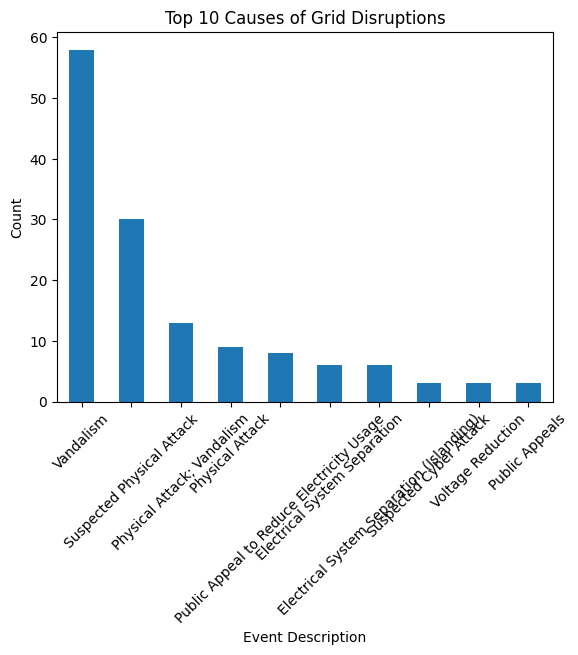

In [8]:
import matplotlib.pyplot as plt

df['Event_Description'].value_counts().head(10).plot(kind='bar')

plt.title('Top 10 Causes of Grid Disruptions')
plt.xlabel('Event Description')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

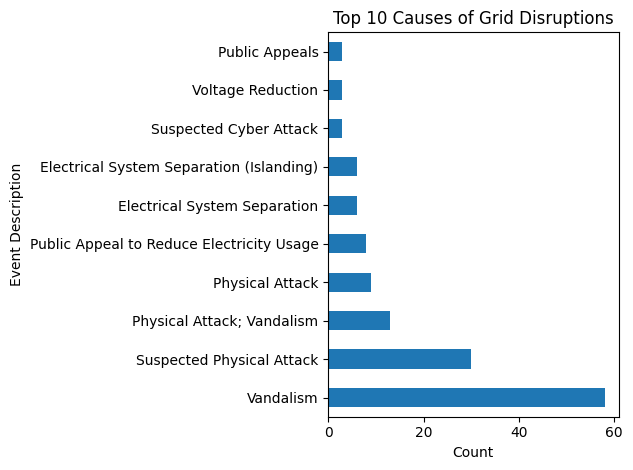

In [9]:
top_causes = df['Event_Description'].value_counts().head(10)

top_causes.plot(kind='barh')

plt.title('Top 10 Causes of Grid Disruptions')
plt.xlabel('Count')
plt.ylabel('Event Description')
plt.tight_layout()
plt.show()

# This chart shows the most common causes of grid disruptions.
# Vandalism and physical attacks appear frequently, along with operational issues.
# This suggests that both human-related events and system conditions play a role in grid reliability.

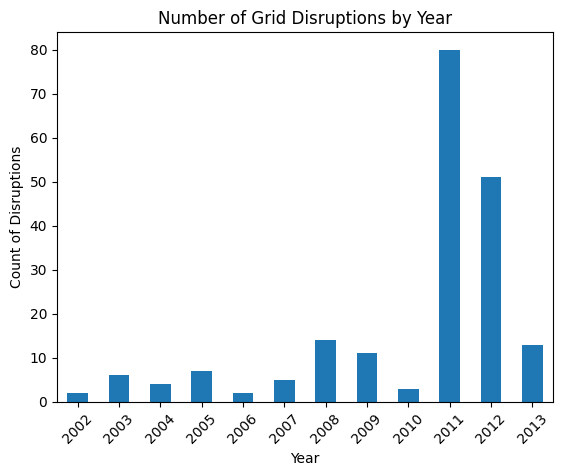

In [10]:
df['Year'].value_counts().sort_index().plot(kind='bar')

plt.title('Number of Grid Disruptions by Year')
plt.xlabel('Year')
plt.ylabel('Count of Disruptions')
plt.xticks(rotation=45)
plt.show()

# The number of grid disruptions varies significantly by year.
# There is a noticeable spike in disruptions around 2011 and 2012,
# while earlier years show relatively lower and more stable counts.

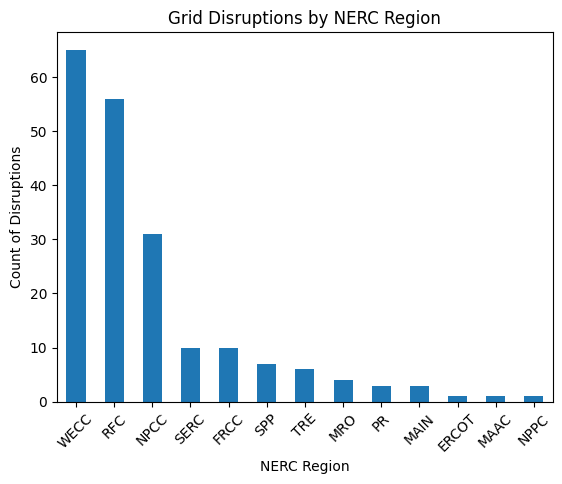

In [11]:
df['NERC_Region'].value_counts().plot(kind='bar')

plt.title('Grid Disruptions by NERC Region')
plt.xlabel('NERC Region')
plt.ylabel('Count of Disruptions')
plt.xticks(rotation=45)
plt.show()

# This chart shows that grid disruptions are not evenly distributed across NERC regions.
# Regions such as WECC and RFC experience a higher number of disruptions,
# while other regions report significantly fewer events.
# It is also important to note that El Paso Electric operates within the WECC region,
# even though most of Texas falls under ERCOT.

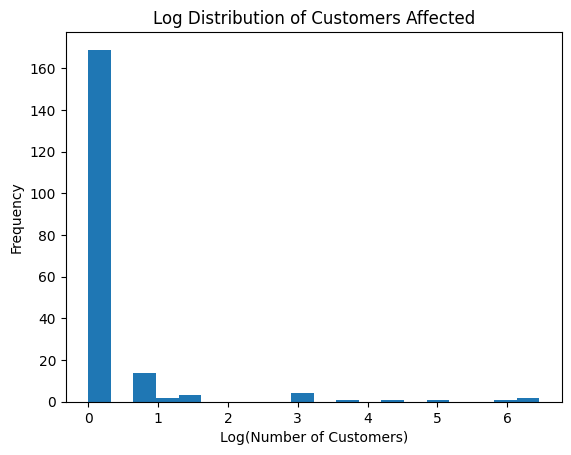

In [13]:
import numpy as np

np.log1p(df['Number_of_Customers_Affected']).plot(kind='hist', bins=20)

plt.title('Log Distribution of Customers Affected')
plt.xlabel('Log(Number of Customers)')
plt.ylabel('Frequency')
plt.show()

# Applying a log transformation helps reduce skewness in the data
# and provides a clearer visualization of the distribution.
# It highlights both small and large disruption events more effectively.